
#Investigation into data privacy and its impact on fraud management in E-commerce business

Dataset Link: https://www.kaggle.com/datasets/aryanrastogi7767/ecommerce-fraud-data

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
os.environ['KAGGLE_CONFIG_DIR'] = '/content'

In [ ]:
!kaggle datasets download -d aryanrastogi7767/ecommerce-fraud-data
!unzip ecommerce-fraud-data.zip

ecommerce-fraud-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  ecommerce-fraud-data.zip
replace Customer_DF (1).csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
customerdf= '/content/Customer_DF (1).csv'
transactiondf='/content/cust_transaction_details (1).csv'

# Read the files

In [ ]:
cust_df= pd.read_csv(customerdf)
trans_df=pd.read_csv(transactiondf)

# Reviewing customer_df dataset

In [ ]:
cust_df.columns

Index(['Unnamed: 0', 'customerEmail', 'customerPhone', 'customerDevice',
       'customerIPAddress', 'customerBillingAddress', 'No_Transactions',
       'No_Orders', 'No_Payments', 'Fraud'],
      dtype='object')

In [ ]:
cust_df.head()

,Unnamed: 0,customerEmail,customerPhone,customerDevice,customerIPAddress,customerBillingAddress,No_Transactions,No_Orders,No_Payments,Fraud
0,0,josephhoward@yahoo.com,400-108-5415,yyeiaxpltf82440jnb3v,8.129.104.40,"5493 Jones Islands\nBrownside, CA 51896",2,2,1,False
1,1,evansjeffery@yahoo.com,1-788-091-7546,r0jpm7xaeqqa3kr6mzum,219.173.211.202,356 Elizabeth Inlet Suite 120\nPort Joshuabury...,3,3,7,True
2,2,andersonwilliam@yahoo.com,024.420.0375,4m7h5ipl1shyavt6vv2r,67b7:3db8:67e0:3bea:b9d0:90c1:2b60:b9f0,"8478 Sean Ridges Apt. 441\nDavisberg, PR 72250",5,3,2,False
3,3,rubenjuarez@yahoo.com,670.664.8168x94985,slovx60t0i558may4ks0,95de:8565:5a66:792c:26e0:6cfb:7d87:11af,"7769 Elizabeth Bridge Apt. 343\nNortonstad, FM...",3,3,1,False
4,4,uchen@malone.com,1-981-877-0870,j0pd24k5h8dl2fqu0cz4,196.89.235.192,"148 Russell Lodge Apt. 445\nPort Jenniferside,...",7,7,6,True


In [ ]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Unnamed: 0              168 non-null    int64 
 1   customerEmail           168 non-null    object
 2   customerPhone           168 non-null    object
 3   customerDevice          168 non-null    object
 4   customerIPAddress       168 non-null    object
 5   customerBillingAddress  168 non-null    object
 6   No_Transactions         168 non-null    int64 
 7   No_Orders               168 non-null    int64 
 8   No_Payments             168 non-null    int64 
 9   Fraud                   168 non-null    bool  
dtypes: bool(1), int64(4), object(5)
memory usage: 12.1+ KB


In [ ]:
cust_df.describe()

,Unnamed: 0,No_Transactions,No_Orders,No_Payments
count,168.000000,168.000000,168.000000,168.000000
mean,83.500000,3.708333,2.845238,2.035714
std,48.641546,2.801527,1.981919,2.113240
min,0.000000,0.000000,0.000000,0.000000
25%,41.750000,1.000000,1.000000,1.000000
50%,83.500000,4.000000,3.000000,1.000000
75%,125.250000,5.000000,4.000000,2.000000
max,167.000000,15.000000,8.000000,15.000000


# Reviewing transaction dataset

In [ ]:
trans_df.columns

Index(['Unnamed: 0', 'customerEmail', 'transactionId', 'orderId',
       'paymentMethodId', 'paymentMethodRegistrationFailure',
       'paymentMethodType', 'paymentMethodProvider', 'transactionAmount',
       'transactionFailed', 'orderState'],
      dtype='object')

In [ ]:
trans_df.head()

,Unnamed: 0,customerEmail,transactionId,orderId,paymentMethodId,paymentMethodRegistrationFailure,paymentMethodType,paymentMethodProvider,transactionAmount,transactionFailed,orderState
0,0,josephhoward@yahoo.com,a9lcj51r,vjbdvd,wt07xm68b,1,card,JCB 16 digit,18,0,pending
1,1,josephhoward@yahoo.com,y4wcv03i,yp6x27,wt07xm68b,1,card,JCB 16 digit,26,0,fulfilled
2,2,evansjeffery@yahoo.com,5mi94sfw,nlghpa,41ug157xz,0,bitcoin,American Express,45,0,fulfilled
3,3,evansjeffery@yahoo.com,br8ba1nu,uw0eeb,41ug157xz,0,bitcoin,American Express,23,0,fulfilled
4,4,evansjeffery@yahoo.com,a33145ss,bn44oh,y3xp697jx,1,bitcoin,VISA 16 digit,43,1,fulfilled


In [ ]:
trans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Unnamed: 0                        623 non-null    int64 
 1   customerEmail                     623 non-null    object
 2   transactionId                     623 non-null    object
 3   orderId                           623 non-null    object
 4   paymentMethodId                   623 non-null    object
 5   paymentMethodRegistrationFailure  623 non-null    int64 
 6   paymentMethodType                 623 non-null    object
 7   paymentMethodProvider             623 non-null    object
 8   transactionAmount                 623 non-null    int64 
 9   transactionFailed                 623 non-null    int64 
 10  orderState                        623 non-null    object
dtypes: int64(4), object(7)
memory usage: 53.7+ KB


In [ ]:
trans_df.describe()

,Unnamed: 0,paymentMethodRegistrationFailure,transactionAmount,transactionFailed
count,623.000000,623.000000,623.000000,623.000000
mean,311.000000,0.131621,34.598716,0.269663
std,179.988889,0.338350,20.360247,0.444141
min,0.000000,0.000000,10.000000,0.000000
25%,155.500000,0.000000,21.000000,0.000000
50%,311.000000,0.000000,34.000000,0.000000
75%,466.500000,0.000000,45.000000,1.000000
max,622.000000,1.000000,353.000000,1.000000


# EDA and Data Visualisations

Data Cleaning and check missing value

In [ ]:
cust_df.duplicated().any()

False

In [ ]:
cust_df.isna().any()

Unnamed: 0                False
customerEmail             False
customerPhone             False
customerDevice            False
customerIPAddress         False
customerBillingAddress    False
No_Transactions           False
No_Orders                 False
No_Payments               False
Fraud                     False
dtype: bool

In [ ]:
trans_df.duplicated().any()

False

In [ ]:
trans_df.isna().any()

Unnamed: 0                          False
customerEmail                       False
transactionId                       False
orderId                             False
paymentMethodId                     False
paymentMethodRegistrationFailure    False
paymentMethodType                   False
paymentMethodProvider               False
transactionAmount                   False
transactionFailed                   False
orderState                          False
dtype: bool

Checking for number of different custoemr email ids present in both the datasets

In [ ]:
cust_df['customerEmail'].nunique()

161

In [ ]:
trans_df['customerEmail'].nunique()

136

checking for repeatation in the customer_df dataset, bacause it is showing 168 in info()

In [ ]:
total_mail=[]
Repeat=0
response={}

In [ ]:
for i in range(0,168):
  Repeat=0
  for j in range(0,168):
    if cust_df['customerEmail'][i] == cust_df['customerEmail'][j]:
      Repeat=Repeat+1
  response.update({cust_df['customerEmail'][i]:Repeat})
response

{'josephhoward@yahoo.com': 1,
 'evansjeffery@yahoo.com': 1,
 'andersonwilliam@yahoo.com': 1,
 'rubenjuarez@yahoo.com': 1,
 'uchen@malone.com': 1,
 'robinsoncynthia@dunn.com': 1,
 'samuel15@saunders-rhodes.com': 1,
 'johnlowery@gmail.com': 8,
 'jameslandry@rodriguez.com': 1,
 'ubranch@rivera-parker.info': 1,
 'bowenwilliam@yahoo.com': 1,
 'ksummers@hotmail.com': 1,
 'christineklein@wright-boyd.org': 1,
 'meganwalters@chavez.com': 1,
 'caleb94@sutton.info': 1,
 'gonzalesjackson@gmail.com': 1,
 'dana09@yahoo.com': 1,
 'alec27@bell.com': 1,
 'juliecook@hotmail.com': 1,
 'meganberry@clark.biz': 1,
 'psantiago@nelson.net': 1,
 'harrisnicholas@mitchell-hancock.com': 1,
 'davismike@hotmail.com': 1,
 'guerramichael@hotmail.com': 1,
 'natalie98@yahoo.com': 1,
 'karen54@mullins.biz': 1,
 'avaldez@gmail.com': 1,
 'blackjoel@wright.com': 1,
 'abigail08@yahoo.com': 1,
 'catherine64@gmail.com': 1,
 'romerolauren@hotmail.com': 1,
 'qramsey@hotmail.com': 1,
 '9es7t@u6n7x': 1,
 'ypruitt@hotmail.com': 1,

hence, it is signified that the name of johnlowery@gmail.com comes 8 times in this email list, to prove its fraud activity, his trasnaction is shown below

In [ ]:
cust_df[cust_df['customerEmail']=='johnlowery@gmail.com']

,Unnamed: 0,customerEmail,customerPhone,customerDevice,customerIPAddress,customerBillingAddress,No_Transactions,No_Orders,No_Payments,Fraud
7,7,johnlowery@gmail.com,044-642-9860,rjb0adai34izqvys4938,212.144.68.190,"484 Pamela Pass\nLake Jessicaview, WI 12942-9074",6,5,2,True
40,40,johnlowery@gmail.com,737-377-9701x577,jz66ap43id2y35ivfqa5,6c21:ac1d:2089:68fa:abb7:8c00:525f:6588,"08238 Kyle Squares Suite 893\nMillermouth, IN ...",0,0,1,True
45,45,johnlowery@gmail.com,+16(4)9016414340,cdx178qymd6vy77nm4x3,222.79.159.140,"77711 Pamela Ridge\nNew Kayla, IL 27182",3,2,1,True
65,65,johnlowery@gmail.com,04712252182,311kdz4c1210iixltk2j,42b3:df19:86fe:abd9:dafe:f6c1:eb76:c72,"11704 Andrew Villages Apt. 035\nJamesfurt, OR ...",7,5,1,True
79,79,johnlowery@gmail.com,1-820-539-4726x993,2in0fh7lep289n8dcbdz,163.128.139.42,"814 Wagner Union\nAshleymouth, HI 35617",2,2,1,True
133,133,johnlowery@gmail.com,1-143-059-1833,tyijaify2hqadwslejyr,e4c:fb48:8ee2:9819:6ae8:8d3f:3b6a:a788,"518 Wood Mews Apt. 970\nDillonstad, NE 43317-3945",0,0,0,True
155,155,johnlowery@gmail.com,076-099-0630x72770,6qy6oa3nqutsyyxzc54c,f259:657f:f329:2fca:c06c:8b57:d6ac:2380,"687 Rogers Bridge Suite 780\nValdezburgh, IN 2...",6,5,3,True
165,165,johnlowery@gmail.com,635.676.0955x524,969zz9zdj8z4gns4sx5p,f82c:811f:8a02:e2d6:79b:fcaa:42de:570b,"548 Bryant Inlet\nVeronicaside, OK 00522",4,4,2,True


**Data Visualisation **

explore the most preffered transation method

In [76]:
trans_df['paymentMethodType'].unique()

array(['card', 'bitcoin', 'apple pay', 'paypal'], dtype=object)

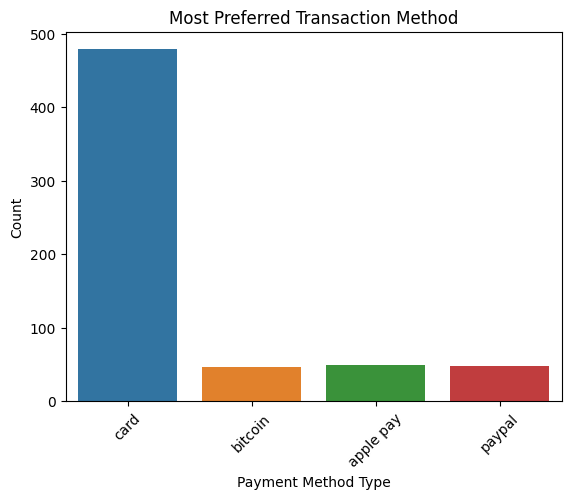

In [78]:
sns.countplot(x='paymentMethodType', data=trans_df)
plt.xticks(rotation=45)  # Rotating x-axis labels for better readability
plt.xlabel('Payment Method Type')
plt.ylabel('Count')
plt.title('Most Preferred Transaction Method')
plt.show()

Payment Status appear often

<Axes: xlabel='paymentMethodType', ylabel='count'>

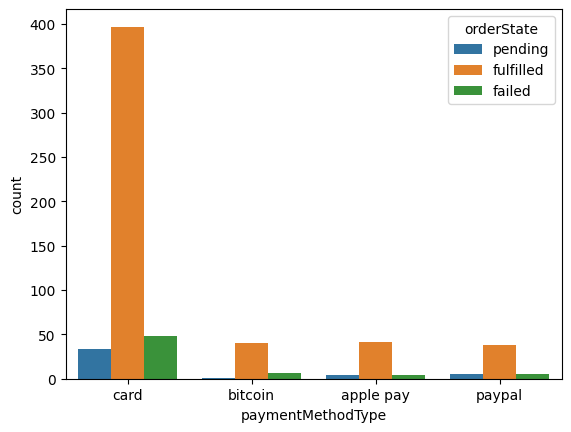

In [79]:
sns.countplot(x='paymentMethodType', hue='orderState', data= trans_df)

Most Failed Payment gateway

<Axes: xlabel='paymentMethodProvider', ylabel='count'>

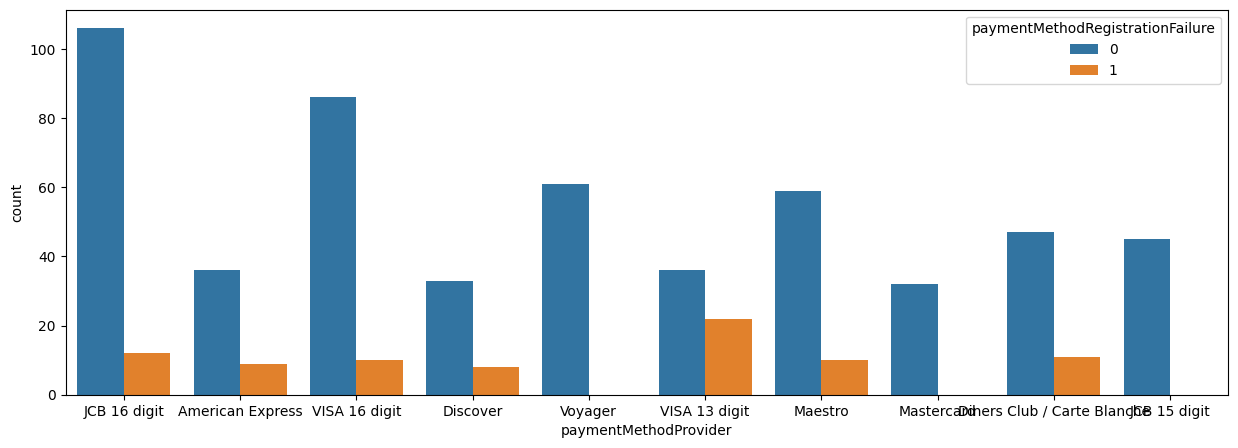

In [81]:
plt.figure(figsize=(15,5))
sns.countplot(x='paymentMethodProvider',hue = 'paymentMethodRegistrationFailure', data=trans_df)

No of Fraud Per transaction

<Axes: xlabel='No_Payments', ylabel='count'>

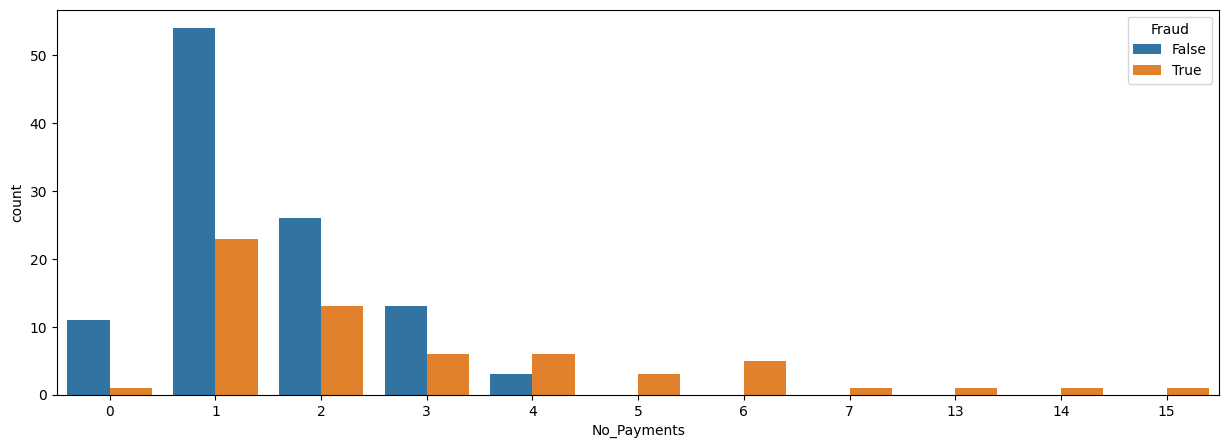

In [83]:
plt.figure(figsize=(15,5))
sns.countplot(x = 'No_Payments',hue = 'Fraud',data=cust_df)

Comparing Fraud and Non Fraud Transaction in Customer_df

<Axes: xlabel='Fraud', ylabel='count'>

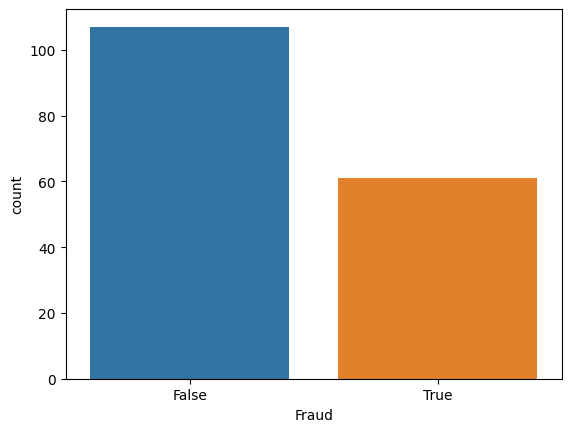

In [84]:
sns.countplot(x='Fraud', data= cust_df)

# Merging the dataset to see the fraud pattrns and Drop Colums that have no effect

In [ ]:
final_df= cust_df[cust_df['customerEmail'].isin(trans_dt['customerEmail'])]

NameError: ignored